In [3]:
#++++++++ SVM +++++++++++
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Step 2: Load dataset
df = pd.read_csv(r"C:\Users\91950\Desktop\fertilizer_recommendation.csv")

# Step 3: Features & Target
X = df.drop("Recommended_Fertilizer", axis=1)
y = df["Recommended_Fertilizer"]

# Step 4: Encode categorical features
X = pd.get_dummies(X)

# Encode target if needed
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 6: Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 7: Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

# Step 8: GridSearchCV
grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

# Step 9: Best model
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# Step 10: Predictions
y_pred = best_model.predict(X_test)

# Step 11: Metrics (in %)
accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred, average='weighted') * 100
recall = recall_score(y_test, y_pred, average='weighted') * 100
f1 = f1_score(y_test, y_pred, average='weighted') * 100

print(f"\nAccuracy  : {accuracy:.2f}%")
print(f"Precision : {precision:.2f}%")
print(f"Recall    : {recall:.2f}%")
print(f"F1 Score  : {f1:.2f}%")

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}

Accuracy  : 79.85%
Precision : 78.81%
Recall    : 79.85%
F1 Score  : 78.83%


In [82]:
#Random Forest+++++++++++---------

# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Step 2: Load dataset
df = pd.read_csv(r"C:\Users\91950\Desktop\fertilizer_recommendation.csv")

# Step 3: Features & Target
X = df.drop("Recommended_Fertilizer", axis=1)
y = df["Recommended_Fertilizer"]

# Step 4: Encode categorical features
X = pd.get_dummies(X)

# Encode target
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 6: Train Random Forest with tuned hyperparameters
model = RandomForestClassifier(
    n_estimators=50,
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)

model.fit(X_train, y_train)

# Step 7: Predictions
y_pred = model.predict(X_test)

# Step 8: Metrics (in % with 2 decimal places)
accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0) * 100
recall = recall_score(y_test, y_pred, average='weighted') * 100
f1 = f1_score(y_test, y_pred, average='weighted') * 100

print(f"Accuracy  : {accuracy:.2f}%")
print(f"Precision : {precision:.2f}%")
print(f"Recall    : {recall:.2f}%")
print(f"F1 Score  : {f1:.2f}%")

Accuracy  : 86.75%
Precision : 86.20%
Recall    : 86.75%
F1 Score  : 85.91%


In [52]:
#---------+++++++++++
#XGBoost
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from xgboost import XGBClassifier

# Step 2: Load dataset
df = pd.read_csv("fertilizer_recommendation.csv")

# Step 3: Features & Target
X = df.drop("Recommended_Fertilizer", axis=1)
y = df["Recommended_Fertilizer"]

# Step 4: Encode categorical features (IMPORTANT)
X = pd.get_dummies(X)

# Encode target
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 6: Train XGBoost model (tuned)
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train)

# Step 7: Predictions
y_pred = model.predict(X_test)

# Step 8: Metrics (in % with 2 decimal places)
accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred, average='weighted') * 100
recall = recall_score(y_test, y_pred, average='weighted') * 100
f1 = f1_score(y_test, y_pred, average='weighted') * 100

print(f"Accuracy  : {accuracy:.2f}%")
print(f"Precision : {precision:.2f}%")
print(f"Recall    : {recall:.2f}%")
print(f"F1 Score  : {f1:.2f}%")

Accuracy  : 88.55%
Precision : 88.12%
Recall    : 88.55%
F1 Score  : 88.26%


In [66]:
#+++++++++++  Logistic Regression ++++++++++++++

# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Step 2: Load dataset
df = pd.read_csv("fertilizer_recommendation.csv")

# Step 3: Features & Target
X = df.drop("Recommended_Fertilizer", axis=1)
y = df["Recommended_Fertilizer"]

# Step 4: Feature Engineering (optional but useful)
X['N_P_ratio'] = X['Nitrogen_Level'] / (X['Phosphorus_Level'] + 1)
X['N_K_ratio'] = X['Nitrogen_Level'] / (X['Potassium_Level'] + 1)

# Step 5: Encode categorical features
X = pd.get_dummies(X)

# Encode target
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 6: Train-test split (STRATIFIED)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 7: Feature Scaling (VERY IMPORTANT)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 8: Train Logistic Regression
model = LogisticRegression(
    max_iter=1000,        # increase iterations for convergence
    C=1.0,                # regularization strength
    solver='lbfgs'
)

model.fit(X_train, y_train)

# Step 9: Predictions
y_pred = model.predict(X_test)

# Step 10: Metrics (in % with 2 decimal places)
accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0) * 100
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0) * 100
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0) * 100

print(f"Accuracy  : {accuracy:.2f}%")
print(f"Precision : {precision:.2f}%")
print(f"Recall    : {recall:.2f}%")
print(f"F1 Score  : {f1:.2f}%")

Accuracy  : 80.00%
Precision : 79.29%
Recall    : 80.00%
F1 Score  : 79.32%


In [72]:
#+++++++++++++++ ANN  +++++++++++++++

# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Step 2: Load dataset
df = pd.read_csv("fertilizer_recommendation.csv")

# Step 3: Features & Target
X = df.drop("Recommended_Fertilizer", axis=1)
y = df["Recommended_Fertilizer"]

# Step 3: Features & Target
X = df.drop("Recommended_Fertilizer", axis=1)
y = df["Recommended_Fertilizer"]

# Step 4: Encode categorical features
X = pd.get_dummies(X)

# Encode target
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 6: Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 7: Build ANN model
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(32, activation='relu'))
model.add(Dense(len(set(y)), activation='softmax'))

# Step 8: Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 9: Train model
model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)

# Step 10: Predictions
y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)

# Step 11: Metrics (in % with 2 decimal places)
accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred, average='weighted') * 100
recall = recall_score(y_test, y_pred, average='weighted') * 100
f1 = f1_score(y_test, y_pred, average='weighted') * 100

print(f"\nAccuracy  : {accuracy:.2f}%")
print(f"Precision : {precision:.2f}%")
print(f"Recall    : {recall:.2f}%")
print(f"F1 Score  : {f1:.2f}%")

Epoch 1/50


C:\Users\91950\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5953 - loss: 1.1536
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7729 - loss: 0.6885
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8066 - loss: 0.5879
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8235 - loss: 0.5308
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8349 - loss: 0.4917
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8461 - loss: 0.4550
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8556 - loss: 0.4260
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8619 - loss: 0.3999
Epoch 9/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8686 - loss: 0.3756
Epoch 10/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8751 - loss: 0.3603
Epoch 11/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8795 - loss: 0.3422
Epoch 12/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy

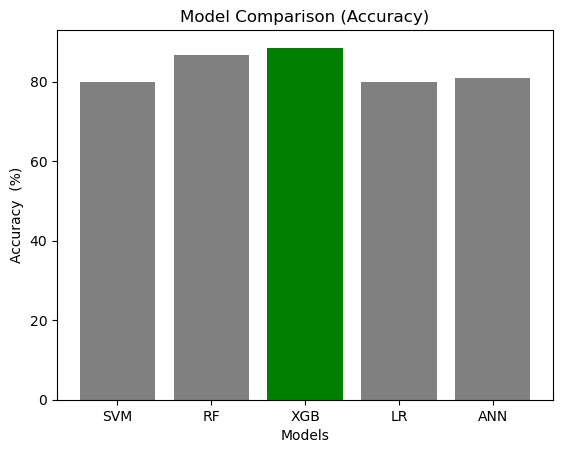

In [98]:
import matplotlib.pyplot as plt

models = ['SVM', 'RF', 'XGB', 'LR', 'ANN']
accuracy = [79.85, 86.75, 88.55, 80, 80.85]

colors = ['gray', 'gray', 'green', 'gray', 'gray']
plt.figure()
plt.bar(models, accuracy, color=colors)

plt.title("Model Comparison (Accuracy)")
plt.xlabel("Models")
plt.ylabel("Accuracy  (%)")

plt.show()

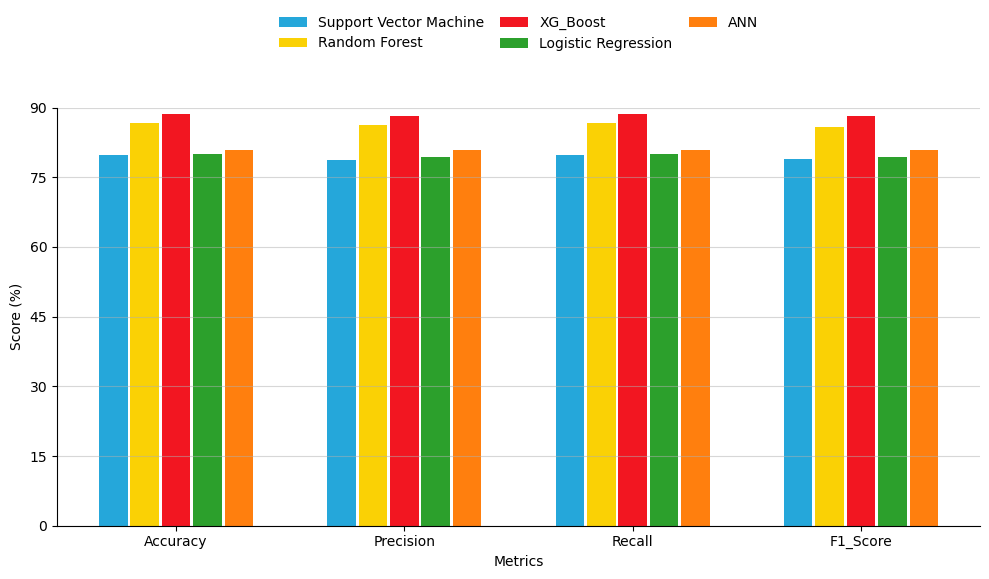

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Labels (x-axis categories)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score']

# models and data
svm = [79.85, 78.81, 79.85, 78.83]
rf = [86.75, 86.20, 86.75, 85.91]
xgb = [88.55, 88.12, 88.55, 88.26]
lgr = [80, 79.29, 80, 79.32]
ann = [80.85, 80.77, 80.85, 80.77]

# X positions
x = np.arange(len(metrics))

# Width of bars
width = 0.2

# Create plot
plt.figure(figsize=(10, 6))

# Plot bars
x = np.arange(len(metrics)) * 0.8
width = 0.10
spacing = 1.1

plt.bar(x - 2*width*spacing, svm, width, label='Support Vector Machine', color='#25A7DA')
plt.bar(x - width*spacing, rf, width, label='Random Forest', color='#FAD105')
plt.bar(x, xgb, width, label='XG_Boost', color='#F21621')
plt.bar(x + width*spacing, lgr, width, label='Logistic Regression', color='#2ca02c')
plt.bar(x + 2*width*spacing, ann, width, label='ANN', color='#ff7f0e')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Labels and title
plt.xlabel('Metrics')
plt.ylabel('Score (%)')


# X ticks
plt.xticks(x, metrics)

# Legend
plt.legend(loc='upper center',
           bbox_to_anchor=(0.5, 1.25),
           ncol=3,
           frameon=False,
           fontsize=10,
           columnspacing=1.2)


# Grid (optional)
plt.grid(axis='y', linestyle='-', linewidth=0.8, alpha=0.5)

# Show plot
plt.ylim(0, 90)
plt.yticks(range(0, 91, 15))
plt.tight_layout()
plt.show()
